In [ ]:
from google.colab import files
uploaded = files.upload()  # Opens a file upload dialog

Saving archive (1).zip to archive (1) (1).zip


In [ ]:
import zipfile
import os

# Extract the zip file
with zipfile.ZipFile("archive (1) (1).zip", 'r') as zip_ref:
    zip_ref.extractall("extracted_data")  # Extract contents into the folder "extracted_data"

# Inspect the extracted folder
print(os.listdir("extracted_data"))  # List the files in the extracted folder

['RiceLeafsDisease']


In [ ]:
# Mount Google Drive
from google.colab import drive

# Path to your dataset
train_dir = '/content/extracted_data/RiceLeafsDisease/train'
validation_dir = '/content/extracted_data/RiceLeafsDisease/validation'

# Import libraries
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Preprocessing function with augmentation
def preprocess_images(data_dir, target_size=(224, 224), augment=False):
    if augment:
        datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=30,
            width_shift_range=0.2,
            height_shift_range=0.2,
            shear_range=0.2,
            zoom_range=0.2,
            horizontal_flip=True,
            fill_mode='nearest'
        )
    else:
        datagen = ImageDataGenerator(rescale=1./255)

    generator = datagen.flow_from_directory(
        data_dir,
        target_size=target_size,
        batch_size=32,
        class_mode='categorical'
    )
    return generator

# Preprocess training and validation data
train_generator = preprocess_images(train_dir, augment=True)
validation_generator = preprocess_images(validation_dir, augment=False)


Found 2100 images belonging to 6 classes.
Found 528 images belonging to 6 classes.


In [ ]:
!fusermount -u /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
os.makedirs('/content/drive/MyDrive/models', exist_ok=True)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Build CNN model
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(train_generator.num_classes, activation='softmax')
])

# Compile and train the CNN model
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn_model.fit(train_generator, validation_data=validation_generator, epochs=10)

# Save the trained CNN model
cnn_model.save('/content/drive/MyDrive/models/cnn_model.h5')

# Evaluate the CNN model
cnn_loss, cnn_accuracy = cnn_model.evaluate(validation_generator)
print(f"CNN Model Accuracy: {cnn_accuracy * 100:.2f}%")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 262s 4s/step - accuracy: 0.2794 - loss: 4.0754 - val_accuracy: 0.5833 - val_loss: 1.1674
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 253s 4s/step - accuracy: 0.5962 - loss: 1.1011 - val_accuracy: 0.5152 - val_loss: 1.1690
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 255s 4s/step - accuracy: 0.6469 - loss: 0.9925 - val_accuracy: 0.5511 - val_loss: 1.1604
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 262s 4s/step - accuracy: 0.6793 - loss: 0.8500 - val_accuracy: 0.7557 - val_loss: 0.6900
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 254s 4s/step - accuracy: 0.7774 - loss: 0.6254 - val_accuracy: 0.8125 - val_loss: 0.5907
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 261s 4s/step - accuracy: 0.7614 - loss: 0.6320 - val_accuracy: 0.8087 - val_loss: 0.5476
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 254s 4s/step - accuracy: 0.7892 - loss: 0.5655 - val_accuracy: 0.7879 - val_loss: 0.6041
Epoch 8/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 260s 4s/step - accuracy: 0.7640 - loss: 0.6431 - val_accuracy: 0.8371 - v

OSError: [Errno 107] Transport endpoint is not connected: '/content/drive/MyDrive'

In [ ]:
cnn_model.save('/content/drive/MyDrive/models/cnn_model.h5')


In [ ]:
# Evaluate CNN model
cnn_loss, cnn_accuracy = cnn_model.evaluate(validation_generator)
print(f"CNN Model Accuracy: {cnn_accuracy * 100:.2f}%")


17/17 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.8532 - loss: 0.4285
CNN Model Accuracy: 83.90%


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# Build ResNet model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

resnet_model = Model(inputs=base_model.input, outputs=predictions)
for layer in base_model.layers:
    layer.trainable = False

# Compile and train the ResNet model
resnet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
resnet_model.fit(train_generator, validation_data=validation_generator, epochs=10)

# Save the trained ResNet model
resnet_model.save('/content/drive/MyDrive/models/resnet_model.h5')

# Evaluate the ResNet model
resnet_loss, resnet_accuracy = resnet_model.evaluate(validation_generator)
print(f"ResNet Model Accuracy: {resnet_accuracy * 100:.2f}%")


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 557s 8s/step - accuracy: 0.1814 - loss: 1.8063 - val_accuracy: 0.2973 - val_loss: 1.5914
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 540s 8s/step - accuracy: 0.3114 - loss: 1.6298 - val_accuracy: 0.3182 - val_loss: 1.5223
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 542s 8s/step - accuracy: 0.2938 - loss: 1.6062 - val_accuracy: 0.3958 - val_loss: 1.4640
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 542s 8s/step - accuracy: 0.3215 - loss: 1.5943 - val_accuracy: 0.3902 - val_loss: 1.4661
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 592s 9s/step - accuracy: 0.3326 - loss: 1.5670 - val_accuracy: 0.3788 - val_loss: 1.4454
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 540s 8s/step - accuracy: 0.3744 - loss: 1.5342 - val_accuracy: 0.3523 - val_loss: 1.4728
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 541s 8s/step - accuracy: 0.3608 - loss: 1.5247 - val_accuracy: 0.4564 - val_loss: 1.4236
Epoch 8/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 541s 8s/step - accurac

17/17 ━━━━━━━━━━━━━━━━━━━━ 104s 6s/step - accuracy: 0.4078 - loss: 1.4706
ResNet Model Accuracy: 41.86%


In [ ]:
from tensorflow.keras.applications import MobileNetV2

# Build MobileNet model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

mobilenet_model = Model(inputs=base_model.input, outputs=predictions)
for layer in base_model.layers:
    layer.trainable = False

# Compile and train the MobileNet model
mobilenet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
mobilenet_model.fit(train_generator, validation_data=validation_generator, epochs=5)

# Save the trained MobileNet model
mobilenet_model.save('/content/drive/MyDrive/models/mobilenet_model.h5')

# Evaluate the MobileNet model
mobilenet_loss, mobilenet_accuracy = mobilenet_model.evaluate(validation_generator)
print(f"MobileNet Model Accuracy: {mobilenet_accuracy * 100:.2f}%")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 203s 3s/step - accuracy: 0.5659 - loss: 1.1309 - val_accuracy: 0.8030 - val_loss: 0.5483
Epoch 2/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 178s 3s/step - accuracy: 0.8341 - loss: 0.4264 - val_accuracy: 0.8598 - val_loss: 0.3808
Epoch 3/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 177s 3s/step - accuracy: 0.8861 - loss: 0.3102 - val_accuracy: 0.9072 - val_loss: 0.2918
Epoch 4/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 204s 3s/step - accuracy: 0.8813 - loss: 0.3023 - val_accuracy: 0.8883 - val_loss: 0.3166
Epoch 5/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 184s 3s/step - accuracy: 0.9111 - loss: 0.2558 - val_accuracy: 0.8845 - val_loss: 0.3158


17/17 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.8921 - loss: 0.3011
MobileNet Model Accuracy: 88.45%


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Extract features using ResNet-50
features_train = resnet_model.predict(train_generator)
features_validation = resnet_model.predict(validation_generator)

# Flatten features
features_train = features_train.reshape(features_train.shape[0], -1)
features_validation = features_validation.reshape(features_validation.shape[0], -1)

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(features_train, train_generator.classes)

# Evaluate Random Forest model
rf_predictions = rf_model.predict(features_validation)
rf_accuracy = accuracy_score(validation_generator.classes, rf_predictions)
print(f"Random Forest Model Accuracy: {rf_accuracy * 100:.2f}%")

# Save the Random Forest model
import pickle
pickle.dump(rf_model, open('/content/drive/MyDrive/models/rf_model.pkl', 'wb'))


66/66 ━━━━━━━━━━━━━━━━━━━━ 448s 7s/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 105s 6s/step
Random Forest Model Accuracy: 17.80%


In [ ]:
import time

# Measure CNN inference time
start_time = time.time()
cnn_model.predict(validation_generator[0][0])  # Predict on a batch of validation data
cnn_inference_time = time.time() - start_time
print(f"CNN Inference Time: {cnn_inference_time:.2f} seconds")

# Measure ResNet inference time
start_time = time.time()
resnet_model.predict(validation_generator[0][0])  # Predict on a batch of validation data
resnet_inference_time = time.time() - start_time
print(f"ResNet Inference Time: {resnet_inference_time:.2f} seconds")

# Measure MobileNet inference time
start_time = time.time()
mobilenet_model.predict(validation_generator[0][0])  # Predict on a batch of validation data
mobilenet_inference_time = time.time() - start_time
print(f"MobileNet Inference Time: {mobilenet_inference_time:.2f} seconds")

# Measure Random Forest inference time
features_validation_flat = features_validation.reshape(features_validation.shape[0], -1)
start_time = time.time()
rf_model.predict(features_validation_flat)  # Predict on flattened validation features
rf_inference_time = time.time() - start_time
print(f"Random Forest Inference Time: {rf_inference_time:.2f} seconds")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
CNN Inference Time: 3.69 seconds
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
ResNet Inference Time: 8.33 seconds
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
MobileNet Inference Time: 5.70 seconds
Random Forest Inference Time: 0.03 seconds


In [ ]:
import os

# Get the size of CNN model
cnn_size = os.path.getsize('/content/drive/MyDrive/models/cnn_model.h5') / 1e6
print(f"CNN Model Size: {cnn_size:.2f} MB")

# Get the size of ResNet model
resnet_size = os.path.getsize('/content/drive/MyDrive/models/resnet_model.h5') / 1e6
print(f"ResNet Model Size: {resnet_size:.2f} MB")

# Get the size of MobileNet model
mobilenet_size = os.path.getsize('/content/drive/MyDrive/models/mobilenet_model.h5') / 1e6
print(f"MobileNet Model Size: {mobilenet_size:.2f} MB")

# Get the size of Random Forest model
rf_size = os.path.getsize('/content/drive/MyDrive/models/rf_model.pkl') / 1e6
print(f"Random Forest Model Size: {rf_size:.2f} MB")


CNN Model Size: 286.94 MB
ResNet Model Size: 98.10 MB
MobileNet Model Size: 11.55 MB
Random Forest Model Size: 19.51 MB


           Model  Accuracy (%)  Inference Time (seconds)  Model Size (MB)
0            CNN     83.901513                  3.688409       286.938456
1         ResNet     41.856059                  8.333091        98.098320
2      MobileNet     88.446969                  5.702055        11.548512
3  Random Forest     17.803030                  0.026668        19.508735


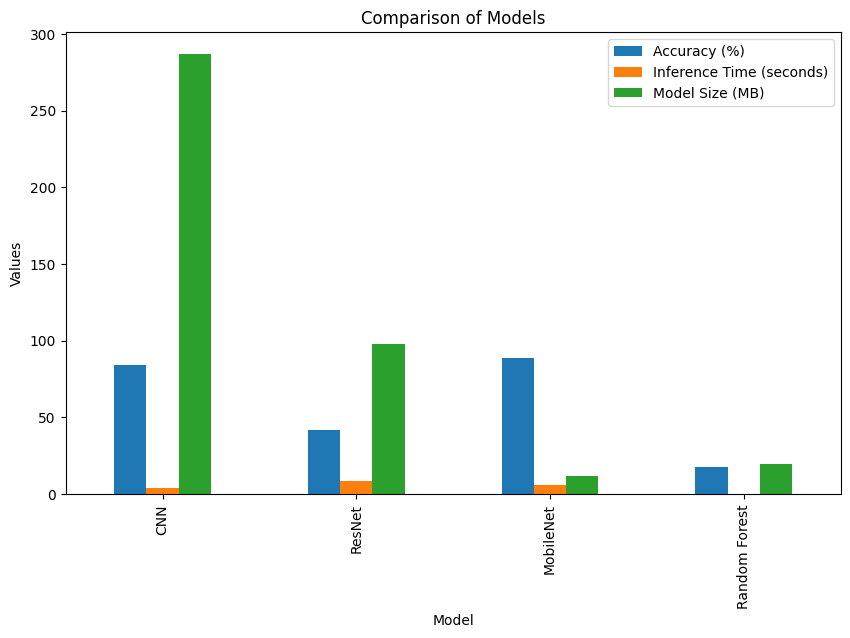

In [ ]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Define model names
models = ['CNN', 'ResNet', 'MobileNet', 'Random Forest']

# Add your computed results from evaluations
accuracy = [cnn_accuracy * 100, resnet_accuracy * 100, mobilenet_accuracy * 100, rf_accuracy * 100]
inference_time = [cnn_inference_time, resnet_inference_time, mobilenet_inference_time, rf_inference_time]
model_size = [cnn_size, resnet_size, mobilenet_size, rf_size]

# Create a DataFrame for comparison
comparison_table = pd.DataFrame({
    'Model': models,
    'Accuracy (%)': accuracy,
    'Inference Time (seconds)': inference_time,
    'Model Size (MB)': model_size
})

# Print the comparison table
print(comparison_table)

# Plot comparison metrics
comparison_table.plot(x='Model', y=['Accuracy (%)', 'Inference Time (seconds)', 'Model Size (MB)'],
                      kind='bar', figsize=(10, 6))
plt.title("Comparison of Models")
plt.ylabel("Values")
plt.show()
